Use this notebook to extract GTFS Data from 511 to get realtime vehicle locations and speeds.

In [10]:
import pandas as pd
import geopandas as gpd
import requests
from google.transit import gtfs_realtime_pb2
from tqdm import tqdm
import time
from datetime import datetime
from shapely.geometry import Point

In [ ]:
# 511 API
api_key = ''
url = f'https://api.511.org/Transit/VehiclePositions?api_key={api_key}&agency=SC'

columns = ['bus_id', 'trip_id', 'route_id', 'lat', 'lon', 'time', 'speed', 'direction']
selected_routes = ['22', 'Rapid 522', '23', 'Rapid 523', '25', '60']

def fetch_realtime_positions_speeds(api_url, iterations=1, delay=60, existing_bus_data=pd.DataFrame(columns=columns)):
    '''
    This function takes in a 511 API URL, a given number of iterations, and a given delay, in seconds.
    Then, every cycle, it will query 511 for the bus locations, speed, travel direction, etc.
    '''

    count = 0
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    file_path = f"../02-data/cleaned_data/vehicle_route_location_speed_data_{timestamp}.csv"

    try:
        with tqdm(total=iterations) as progress_bar:
            while count < iterations:
                response = requests.get(api_url)

                if response.status_code == 200:
                    
                    try:
                        #Get GTFS response
                        feed = gtfs_realtime_pb2.FeedMessage()
                        feed.ParseFromString(response.content)

                        data_list = []

                        #For each vehicle
                        for entity in feed.entity:
                            if entity.HasField('vehicle'):
                                vehicle = entity.vehicle
                                trip = vehicle.trip
                                route_id = trip.route_id

                                #Check if the route_id is in the list of desired route IDs
                                if route_id in selected_routes:

                                    #Extract the vehicle's details
                                    vehicle_data = {
                                        'bus_id': entity.id,
                                        'trip_id': trip.trip_id,
                                        'route_id': route_id,
                                        'lat': vehicle.position.latitude,
                                        'lon': vehicle.position.longitude,
                                        'time': vehicle.timestamp,
                                        'speed': vehicle.position.speed,
                                        'direction' : trip.direction_id
                                    }

                                    data_list.append(vehicle_data)
                        
                        new_bus_data = pd.DataFrame(data_list, columns=existing_bus_data.columns)
                        existing_bus_data = pd.concat([existing_bus_data, new_bus_data], ignore_index=True)

                    except Exception as e:
                        print(e)
                    
                else:
                    print(f"Error: {response.status_code} - {response.text}")
                
                if count < iterations - 1:  # No delay after the last iteration
                    time.sleep(delay)
                
                count += 1
                progress_bar.update(1)
    
        existing_bus_data.to_csv(file_path, index=False)

    except:
        existing_bus_data.to_csv(file_path, index=False)

    return existing_bus_data

In [12]:
#Interupting this probably forces a kernel restart if running many iterations
#1 hr worth of data = iterations*delay/3600
#probably want delay >= 10 reflect how often the positions are refreshed
bus_data = fetch_realtime_positions_speeds(url, iterations=120, delay = 30)
bus_data.drop_duplicates()

  0%|          | 0/120 [00:00<?, ?it/s]C:\Users\thele\AppData\Local\Temp\ipykernel_28680\2290904101.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  existing_bus_data = pd.concat([existing_bus_data, new_bus_data], ignore_index=True)
100%|██████████| 120/120 [59:51<00:00, 29.93s/it]


,bus_id,trip_id,route_id,lat,lon,time,speed,direction
0,0130,3926108,60,37.293282,-121.950050,1774486047,0.024179,1
1,0131,3926114,60,37.410069,-121.891594,1774486047,0.002058,1
2,0132,3926113,60,37.402996,-121.890724,1774486047,8.093684,1
3,0133,3926109,60,37.300907,-121.950104,1774486047,7.462981,1
4,0134,3926045,60,37.386295,-121.887779,1774486047,11.418509,0
...,...,...,...,...,...,...,...,...
9716,8330,3923700,Rapid 523,37.338432,-121.883705,1774489638,0.001029,1
9717,8335,3916829,22,37.353748,-122.014984,1774489638,0.001029,1
9718,8336,3916833,22,37.342175,-121.924644,1774489638,10.632445,1
9719,8339,3916786,22,37.444080,-122.166084,1774489638,0.001543,0


In [13]:
bus_gdf_geometry = [Point(xy) for xy in zip(bus_data["lon"], bus_data["lat"])]

In [14]:
bus_gdf = gpd.GeoDataFrame(bus_data, geometry=bus_gdf_geometry, crs="EPSG:4326")
bus_gdf = bus_gdf.to_crs("EPSG:2227")
bus_gdf

,bus_id,trip_id,route_id,lat,lon,time,speed,direction,geometry
0,0130,3926108,60,37.293282,-121.950050,1774486047,0.024179,1,POINT (6139870.878 1932526.394)
1,0131,3926114,60,37.410069,-121.891594,1774486047,0.002058,1,POINT (6157505.784 1974786.023)
2,0132,3926113,60,37.402996,-121.890724,1774486047,8.093684,1,POINT (6157720.108 1972207.445)
3,0133,3926109,60,37.300907,-121.950104,1774486047,7.462981,1,POINT (6139898.359 1935302.79)
4,0134,3926045,60,37.386295,-121.887779,1774486047,11.418509,0,POINT (6158485.273 1966114.61)
...,...,...,...,...,...,...,...,...,...
9716,8330,3923700,Rapid 523,37.338432,-121.883705,1774489638,0.001029,1,POINT (6159411.191 1948671.911)
9717,8335,3916829,22,37.353748,-122.014984,1774489638,0.001029,1,POINT (6121340.66 1954838.776)
9718,8336,3916833,22,37.342175,-121.924644,1774489638,10.632445,1,POINT (6147531.407 1950212.872)
9719,8339,3916786,22,37.444080,-122.166084,1774489638,0.001543,0,POINT (6078013.495 1988470.056)


<Axes: >

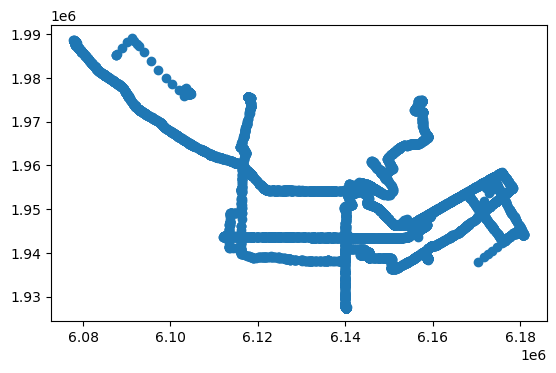

In [15]:
bus_gdf.plot()